In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('house_price_india.csv')
df.head()

,id,date,number_of_bedrooms,number_of_bathrooms,living_area,lot_area,number_of_floors,waterfront_present,number_of_views,condition_of_the_house,grade_of_the_house,area_of_the_house,area_of_the_basement,built_year,renovation_year,postal_code,lattitude,longitude,living_area_renov,lot_area_renov,number_of_schools_nearby,distance_from_the_airport,price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,8,1910,1010,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,8,2910,0,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,9,3310,0,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,8,1880,830,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,9,1700,900,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [3]:
df.shape

(14619, 23)

In [4]:
df.columns

Index(['id', 'date', 'number_of_bedrooms', 'number_of_bathrooms',
       'living_area', 'lot_area', 'number_of_floors', 'waterfront_present',
       'number_of_views', 'condition_of_the_house', 'grade_of_the_house',
       'area_of_the_house', 'area_of_the_basement', 'built_year',
       'renovation_year', 'postal_code', 'lattitude', 'longitude',
       'living_area_renov', 'lot_area_renov', 'number_of_schools_nearby',
       'distance_from_the_airport', 'price'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         14619 non-null  int64  
 1   date                       14619 non-null  int64  
 2   number_of_bedrooms         14619 non-null  int64  
 3   number_of_bathrooms        14619 non-null  float64
 4   living_area                14619 non-null  int64  
 5   lot_area                   14619 non-null  int64  
 6   number_of_floors           14619 non-null  float64
 7   waterfront_present         14619 non-null  int64  
 8   number_of_views            14619 non-null  int64  
 9   condition_of_the_house     14619 non-null  int64  
 10  grade_of_the_house         14619 non-null  int64  
 11  area_of_the_house          14619 non-null  int64  
 12  area_of_the_basement       14619 non-null  int64  
 13  built_year                 14619 non-null  int

In [6]:
stats = df["price"].describe().reset_index()
stats["price"] = round(stats["price"],2)
stats

,index,price
0,count,14619.00
1,mean,538806.28
2,std,367229.36
3,min,78000.00
4,25%,320000.00
5,50%,450000.00
6,75%,645000.00
7,max,7700000.00


In [7]:
df.isna().sum()

id                           0
date                         0
number_of_bedrooms           0
number_of_bathrooms          0
living_area                  0
lot_area                     0
number_of_floors             0
waterfront_present           0
number_of_views              0
condition_of_the_house       0
grade_of_the_house           0
area_of_the_house            0
area_of_the_basement         0
built_year                   0
renovation_year              0
postal_code                  0
lattitude                    0
longitude                    0
living_area_renov            0
lot_area_renov               0
number_of_schools_nearby     0
distance_from_the_airport    0
price                        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.head()

,id,date,number_of_bedrooms,number_of_bathrooms,living_area,lot_area,number_of_floors,waterfront_present,number_of_views,condition_of_the_house,grade_of_the_house,area_of_the_house,area_of_the_basement,built_year,renovation_year,postal_code,lattitude,longitude,living_area_renov,lot_area_renov,number_of_schools_nearby,distance_from_the_airport,price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,8,1910,1010,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,8,2910,0,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,9,3310,0,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,8,1880,830,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,9,1700,900,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


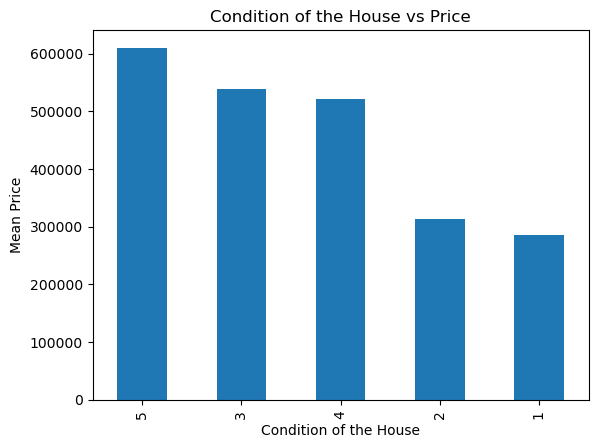

In [10]:
# Avg Price of House based on condition
df.groupby("condition_of_the_house")["price"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Condition of the House vs Price")
plt.xlabel("Condition of the House")
plt.ylabel("Mean Price")
plt.show()

In [11]:
X = df[['number_of_bedrooms', 'number_of_bathrooms','living_area','condition_of_the_house','number_of_schools_nearby']]
y = df['price']

In [12]:
X

,number_of_bedrooms,number_of_bathrooms,living_area,condition_of_the_house,number_of_schools_nearby
0,4,2.50,2920,5,2
1,5,2.75,2910,3,1
2,4,2.50,3310,3,3
3,3,2.00,2710,4,1
4,3,2.50,2600,4,1
...,...,...,...,...,...
14614,2,1.50,1556,4,3
14615,3,2.00,1680,4,3
14616,2,1.00,1070,3,2
14617,4,1.00,1030,4,3


In [13]:
y

0        1400000
1        1200000
2         838000
3         805000
4         790000
          ...   
14614     221700
14615     219200
14616     209000
14617     205000
14618     146000
Name: price, Length: 14619, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [15]:
from sklearn.model_selection import GridSearchCV

In [16]:
from sklearn.tree import DecisionTreeRegressor
param_grid = {
    "criterion" : ["mse","friedman_mse","mae"],
    "splitter" : ["best","random"],
    "max_depth" : [None,10,20,30,40,50],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]
}

In [17]:
tree_model = DecisionTreeRegressor()

In [18]:
grid_tree = GridSearchCV(tree_model,param_grid)

In [19]:
grid_tree.fit(X_train,y_train)

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['mse', 'friedman_mse', 'mae'],
                         'max_depth': [None, 10, 20, 30, 40, 50],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [20]:
grid_tree.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'splitter': 'random'}

In [21]:
tree_pred = grid_tree.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,tree_pred)

163808.77426006077

In [23]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [24]:
lr.fit(X_train,y_train)

LinearRegression()

In [25]:
lr_pred = lr.predict(X_test)

In [26]:
mean_absolute_error(y_test,lr_pred)

163115.23252024016

In [27]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()

In [28]:
param_grid = {
    "max_depth" : [5,10,15],
    "n_estimators" : [2,3,4,5,6,7,8,9,10]
}

In [29]:
grid_rfr = GridSearchCV(rfr,param_grid)

In [30]:
grid_rfr.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [31]:
grid_rfr.best_params_

{'max_depth': 5, 'n_estimators': 9}

In [32]:
rfr_pred = grid_rfr.predict(X_test)

In [33]:
mean_absolute_error(y_test,rfr_pred)

158260.65335942231

In [34]:
grid_rfr

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, 15],
                         'n_estimators': [2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [35]:
import joblib
joblib.dump(grid_rfr,"model.pkl")

['model.pkl']